In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Тестовое _ Данные - Лист1.csv')

In [3]:
df.head()

,Год,Муниципалитет,Пол,Возрастная группа,Причина смерти,Стандартный вес группы,Число умерших,Численность населения
0,2017,Район 1,Женщины,1-4,Болезни сердца,4,0,155
1,2017,Район 1,Женщины,1-4,Другие болезни органов дыхания,4,0,155
2,2017,Район 1,Женщины,1-4,Другие болезни системы кровообращения,4,0,155
3,2017,Район 1,Женщины,1-4,Острые респираторные заболевания,4,0,155
4,2017,Район 1,Женщины,10-14,Болезни сердца,"5,5",0,163


In [4]:
# Определение нужного порядка возрастных групп
age_order = ['до 1', '1-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', 
             '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', 
             '75-79', '80-84', '85+']

In [5]:
# Преобразование колонки 'Возрастная группа' в категориальный тип с фиксированным порядком
df['Возрастная группа'] = pd.Categorical(df['Возрастная группа'], categories=age_order, ordered=True)

In [6]:
# Приведение колонки 'Стандартный вес группы' исходной таблицы к виду 0.01 (т.е. доли, а не проценты).
df['Стандартный вес группы'] = df['Стандартный вес группы'].str.replace(',', '.').astype(float) / 100

In [7]:
# Создание колонки 'Взвешенное число умерших'.
df['Взвешенное число умерших'] = (100000 * df['Стандартный вес группы'] * df['Число умерших'] / df['Численность населения'])

# Распределения по возрастам за весь период для каждого муниципалитета

In [8]:
# Суммирование всех годов и причин смерти внутри группы.
df_group_period=(df.groupby(['Муниципалитет', 'Пол', 'Возрастная группа', 'Стандартный вес группы'], as_index=False)
    .agg({'Число умерших': 'sum', 'Взвешенное число умерших': 'sum', 'Численность населения': 'mean'}))
# Размножение строк по численности населения в группе для использования violinplot.
df_group_period_population=df_group_period.loc[df_group_period.index.repeat(df_group_period['Численность населения'].round())]
# Размножение строк по числу умершихв группе для использования violinplot.
df_group_period_deathes=df_group_period.loc[df_group_period.index.repeat(df_group_period['Взвешенное число умерших'].round())]
# Создание таблицы основы для барплота.
df_group_period_barplot = df_group_period.copy()
# Создание колонки 'Взвешенное число умерших'.
df_group_period_barplot['Взвешенное число умерших'] = (df_group_period_barplot[['Взвешенное число умерших', 'Пол']]
    .apply(lambda x: x['Взвешенное число умерших'] if x['Пол']=='Женщины' else -x['Взвешенное число умерших'], axis=1))

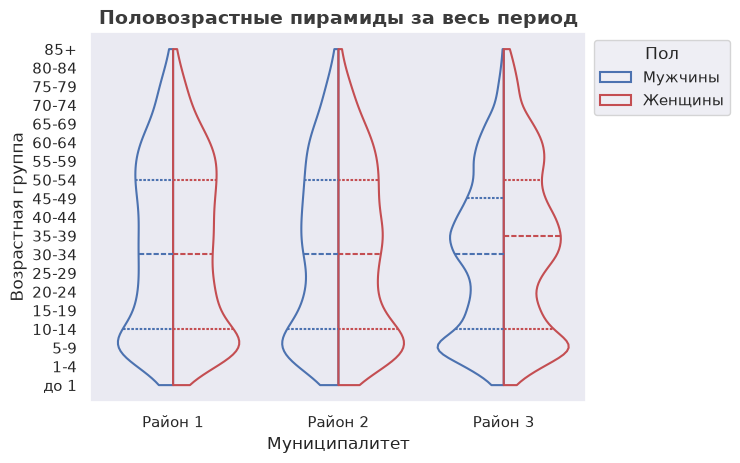

In [9]:
# Построение половозрастной пирамиды.
sns.set_theme(style="dark")
fig, ax = plt.subplots()

sns.violinplot(data=df_group_period_population, x="Муниципалитет", y="Возрастная группа", hue="Пол",
               split=True, inner="quart", fill=False, ax=ax,
               palette={"Мужчины": "b", "Женщины": "r"}, cut=0,
               order=['Район 1', 'Район 2', 'Район 3'],
               hue_order=['Мужчины', 'Женщины']
              )
ax.invert_yaxis()
ax.set_title('Половозрастные пирамиды за весь период', fontsize=14, fontweight='bold', alpha=0.90)
# Перемещение легенды.
legend = plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Пол')

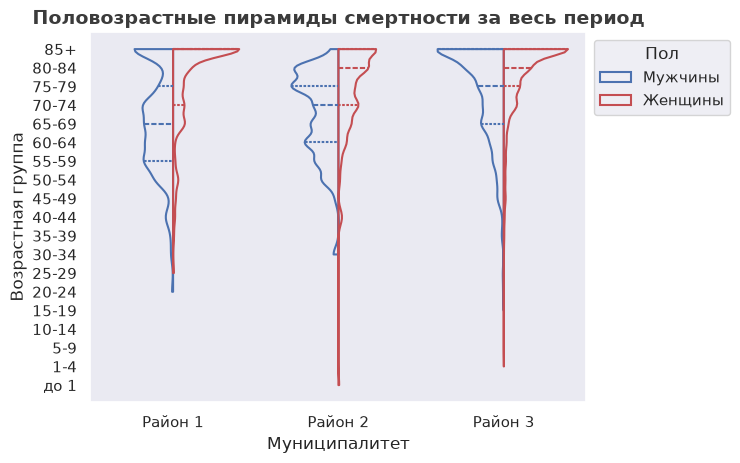

In [10]:
# Построение распределений взвешенного числа умерших по возрастам и полам.
sns.set_theme(style="dark")
fig, ax = plt.subplots()

sns.violinplot(data=df_group_period_deathes, x="Муниципалитет", y="Возрастная группа", hue="Пол",
               split=True, inner="quart", fill=False, ax=ax,
               palette={"Мужчины": "b", "Женщины": "r"}, cut=0,
               order=['Район 1', 'Район 2', 'Район 3'],
               hue_order=['Мужчины', 'Женщины']
              )
ax.invert_yaxis()
ax.set_title('Половозрастные пирамиды смертности за весь период', fontsize=14, fontweight='bold', alpha=0.90)
# Перемещение легенды.
legend = plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Пол')

In [11]:
def draw_pyramid(data, **kwargs):

    order = age_order[::-1]
    # Данные для женщин
    df_women = data[data['Пол'] == 'Женщины']
    # Данные для мужчин
    df_men = data[data['Пол'] == 'Мужчины']
    
    # Текущие оси ячейки
    ax = plt.gca()

    sns.barplot(df_women, x='Взвешенное число умерших', y='Возрастная группа',
                label='Женщины', color='r', errorbar=None, order=order, ax=ax)
    sns.barplot(df_men, x='Взвешенное число умерших', y='Возрастная группа',
                label='Мужчины', color='b', errorbar=None, order=order, ax=ax)

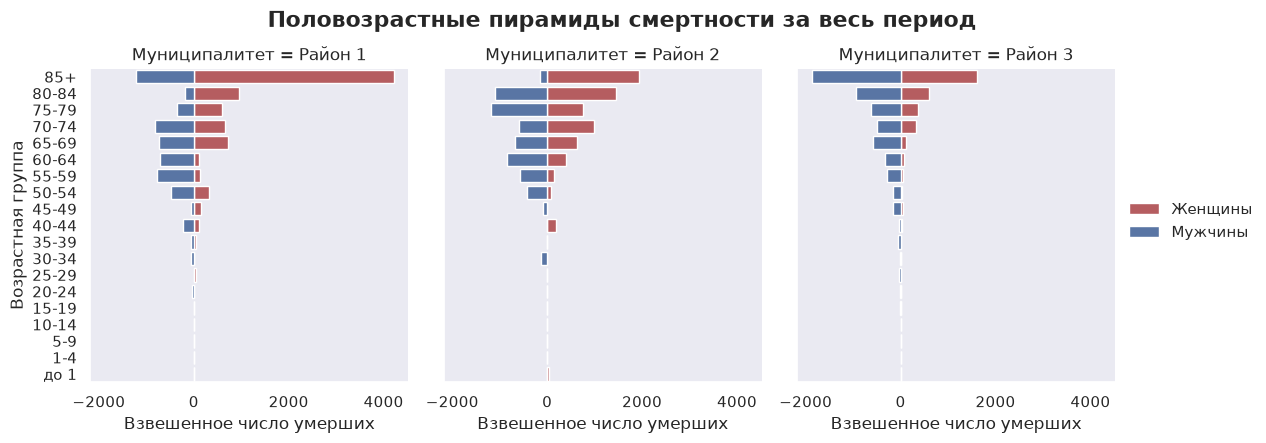

In [12]:
g = sns.FacetGrid(df_group_period_barplot, 
                  col='Муниципалитет',
                  height=4.5, aspect=0.85)
g.map_dataframe(draw_pyramid)
g.fig.suptitle('Половозрастные пирамиды смертности за весь период', 
               fontsize=16, fontweight='bold')
g.fig.subplots_adjust(top=0.85)
g.add_legend()

# Распределения по возрастам и годам для каждого муниципалитета

In [13]:
# Суммирование всех причин смерти внутри группы.
df_group=(df.groupby(['Год', 'Муниципалитет', 'Пол', 'Возрастная группа', 'Стандартный вес группы', 'Численность населения'], as_index=False)
    .agg({'Число умерших': 'sum', 'Взвешенное число умерших': 'sum'}))
# Размножение строк по численности населения в группе для использования violinplot.
df_group_population=df_group.loc[df_group.index.repeat(df_group['Численность населения'])]
# Размножение строк по числу умерших в группе для использования violinplot.
df_group_deathes=df_group.loc[df_group.index.repeat(df_group['Взвешенное число умерших'].round())]
# Создание таблицы основы для барплота.
df_group_barplot = df_group.copy()
# Создание колонки 'Взвешенное число умерших'.
df_group_barplot['Взвешенное число умерших'] = (df_group_barplot[['Взвешенное число умерших', 'Пол']]
    .apply(lambda x: x['Взвешенное число умерших'] if x['Пол']=='Женщины' else -x['Взвешенное число умерших'], axis=1))

## Отдельные

### Половозрастные пирамиды

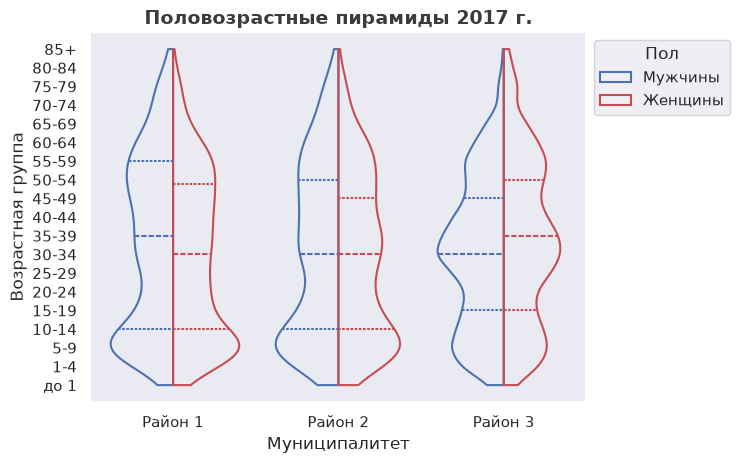

In [14]:
# Построение половозрастных пирамид для выбранного года для всех муниципалитетов.

# Задание года
age = 2017

# Создание рисунка
sns.set_theme(style="dark")
fig, ax = plt.subplots()

sns.violinplot(data=df_group_population[df_group_population['Год']==age], x="Муниципалитет", y="Возрастная группа", hue="Пол",
               split=True, inner="quart", fill=False, ax=ax,
               palette={"Мужчины": "b", "Женщины": "r"}, cut=0,
               order=['Район 1', 'Район 2', 'Район 3'],
               hue_order=['Мужчины', 'Женщины']
              )
# Инвертирование оси y.
ax.invert_yaxis()
# Добавление подписи.
ax.set_title('Половозрастные пирамиды {} г.'.format(age), fontsize=14, fontweight='bold', alpha=0.90)
# Перемещение легенды.
legend = plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Пол')

### Плотности смертности

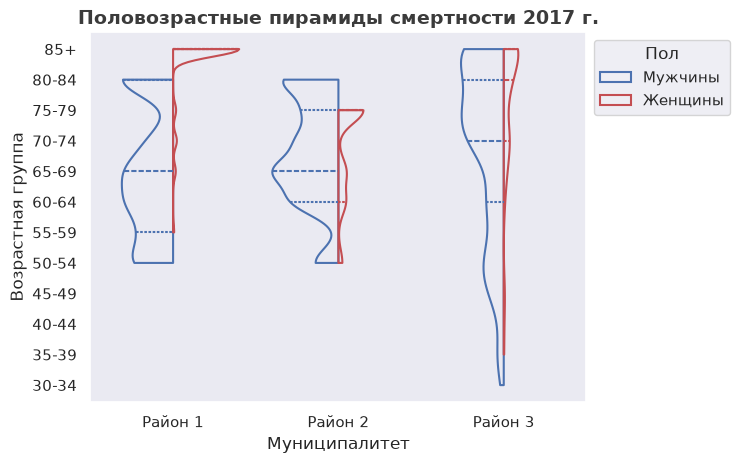

In [15]:
# Построение распределений взвешенного числа умерших по возрастным группам и полам для выбранного года для всех муниципалитетов.

# Задание года
age = 2017

# Создание рисунка
sns.set_theme(style="dark")
fig, ax = plt.subplots()

sns.violinplot(data=df_group_deathes[df_group_deathes['Год']==age], x="Муниципалитет", y="Возрастная группа", hue="Пол",
               split=True, inner="quart", fill=False, ax=ax,
               palette={"Мужчины": "b", "Женщины": "r"}, cut=0,
               order=['Район 1', 'Район 2', 'Район 3'],
               hue_order=['Мужчины', 'Женщины']
              )
# Инвертирование оси y.
ax.invert_yaxis()
# Добавление подписи.
ax.set_title('Половозрастные пирамиды смертности {} г.'.format(age), fontsize=14, fontweight='bold', alpha=0.90)
# Перемещение легенды.
legend = plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Пол')

## Совмещённые

In [16]:
# Создание функции для инвертирования оси y.
def invert_y_axis(**kwargs):
    plt.gca().invert_yaxis()

### Половозрастные пирамиды

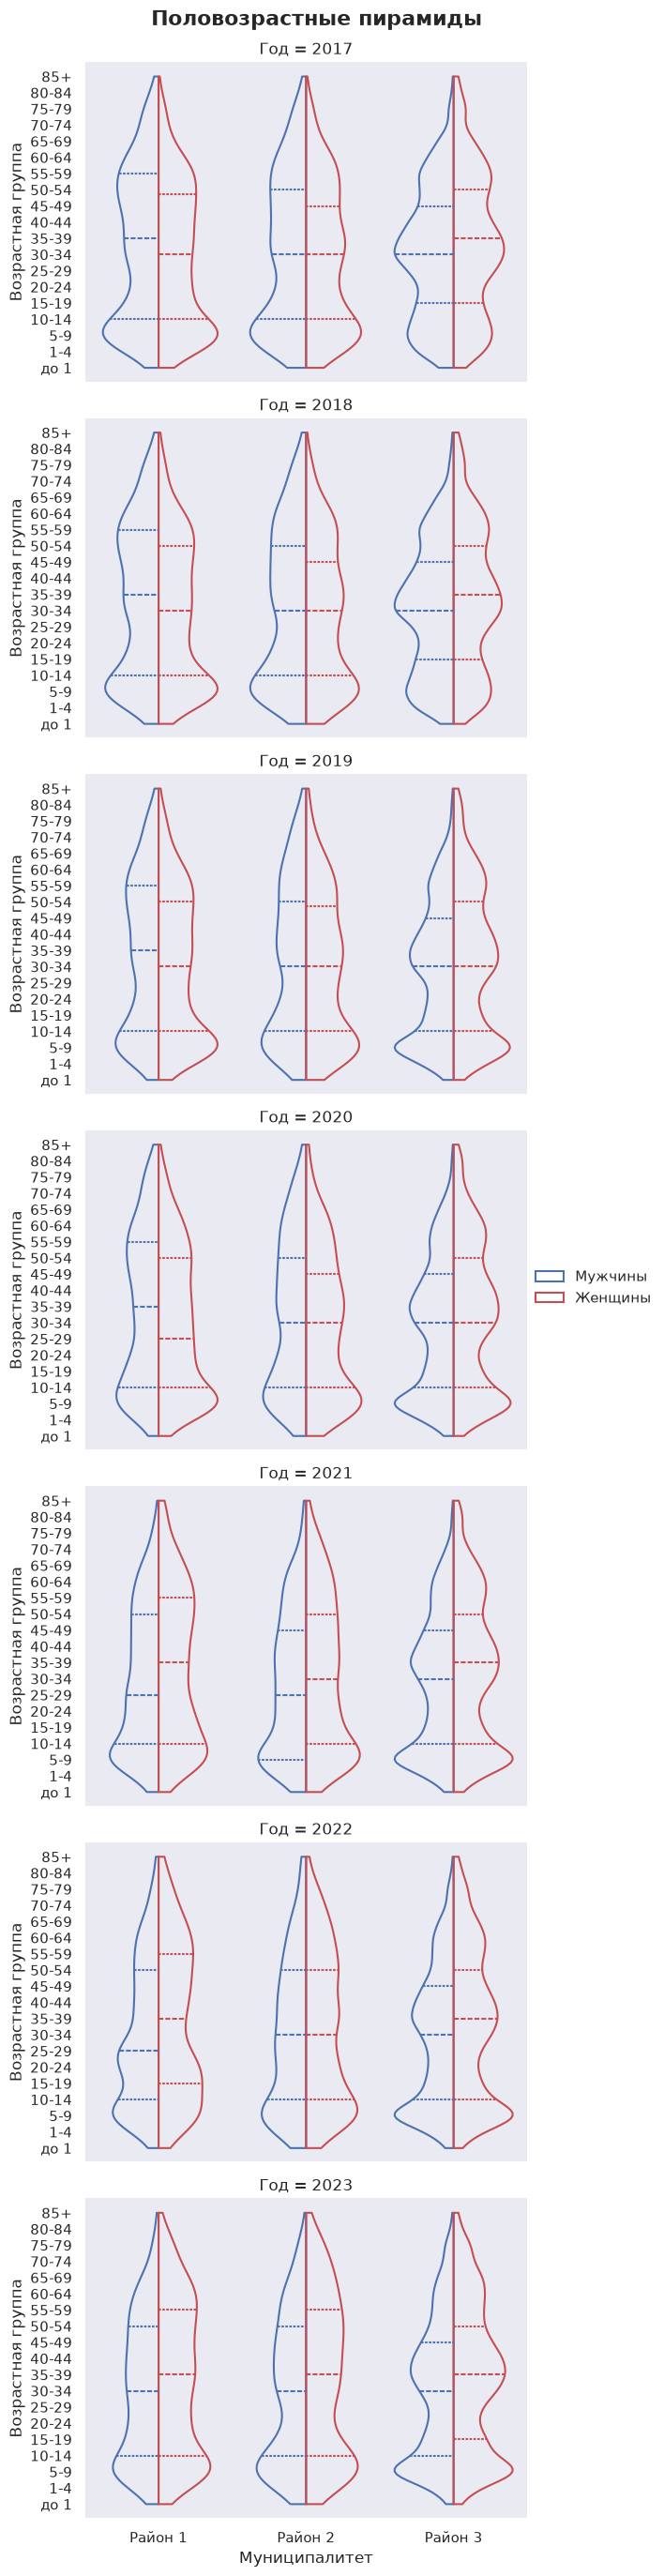

In [17]:
# Построение половозрастных пирамид для всех годов и муниципалитетов с группировкой по годам.

# Создание сетки FacetGrid.
g = sns.FacetGrid(df_group_population, row='Год',
                  height=4, aspect=1.5
                 )
# Создание рисунков в сетке FacetGrid.
g.map_dataframe(sns.violinplot, x="Муниципалитет", y="Возрастная группа", hue='Пол',
                split=True, inner="quart", fill=False,
                palette={"Мужчины": "b", "Женщины": "r"}, cut=0,
                order=['Район 1', 'Район 2', 'Район 3'],
                hue_order=['Мужчины', 'Женщины']
               )
# Инвертирование оси y.
g.map(invert_y_axis)
# Добавление легенды.
g.add_legend()
# Добавление заголовка
g.fig.suptitle('Половозрастные пирамиды', fontsize=16, fontweight='bold')
# Сдвиг картинки вниз
g.fig.subplots_adjust(top=0.96)

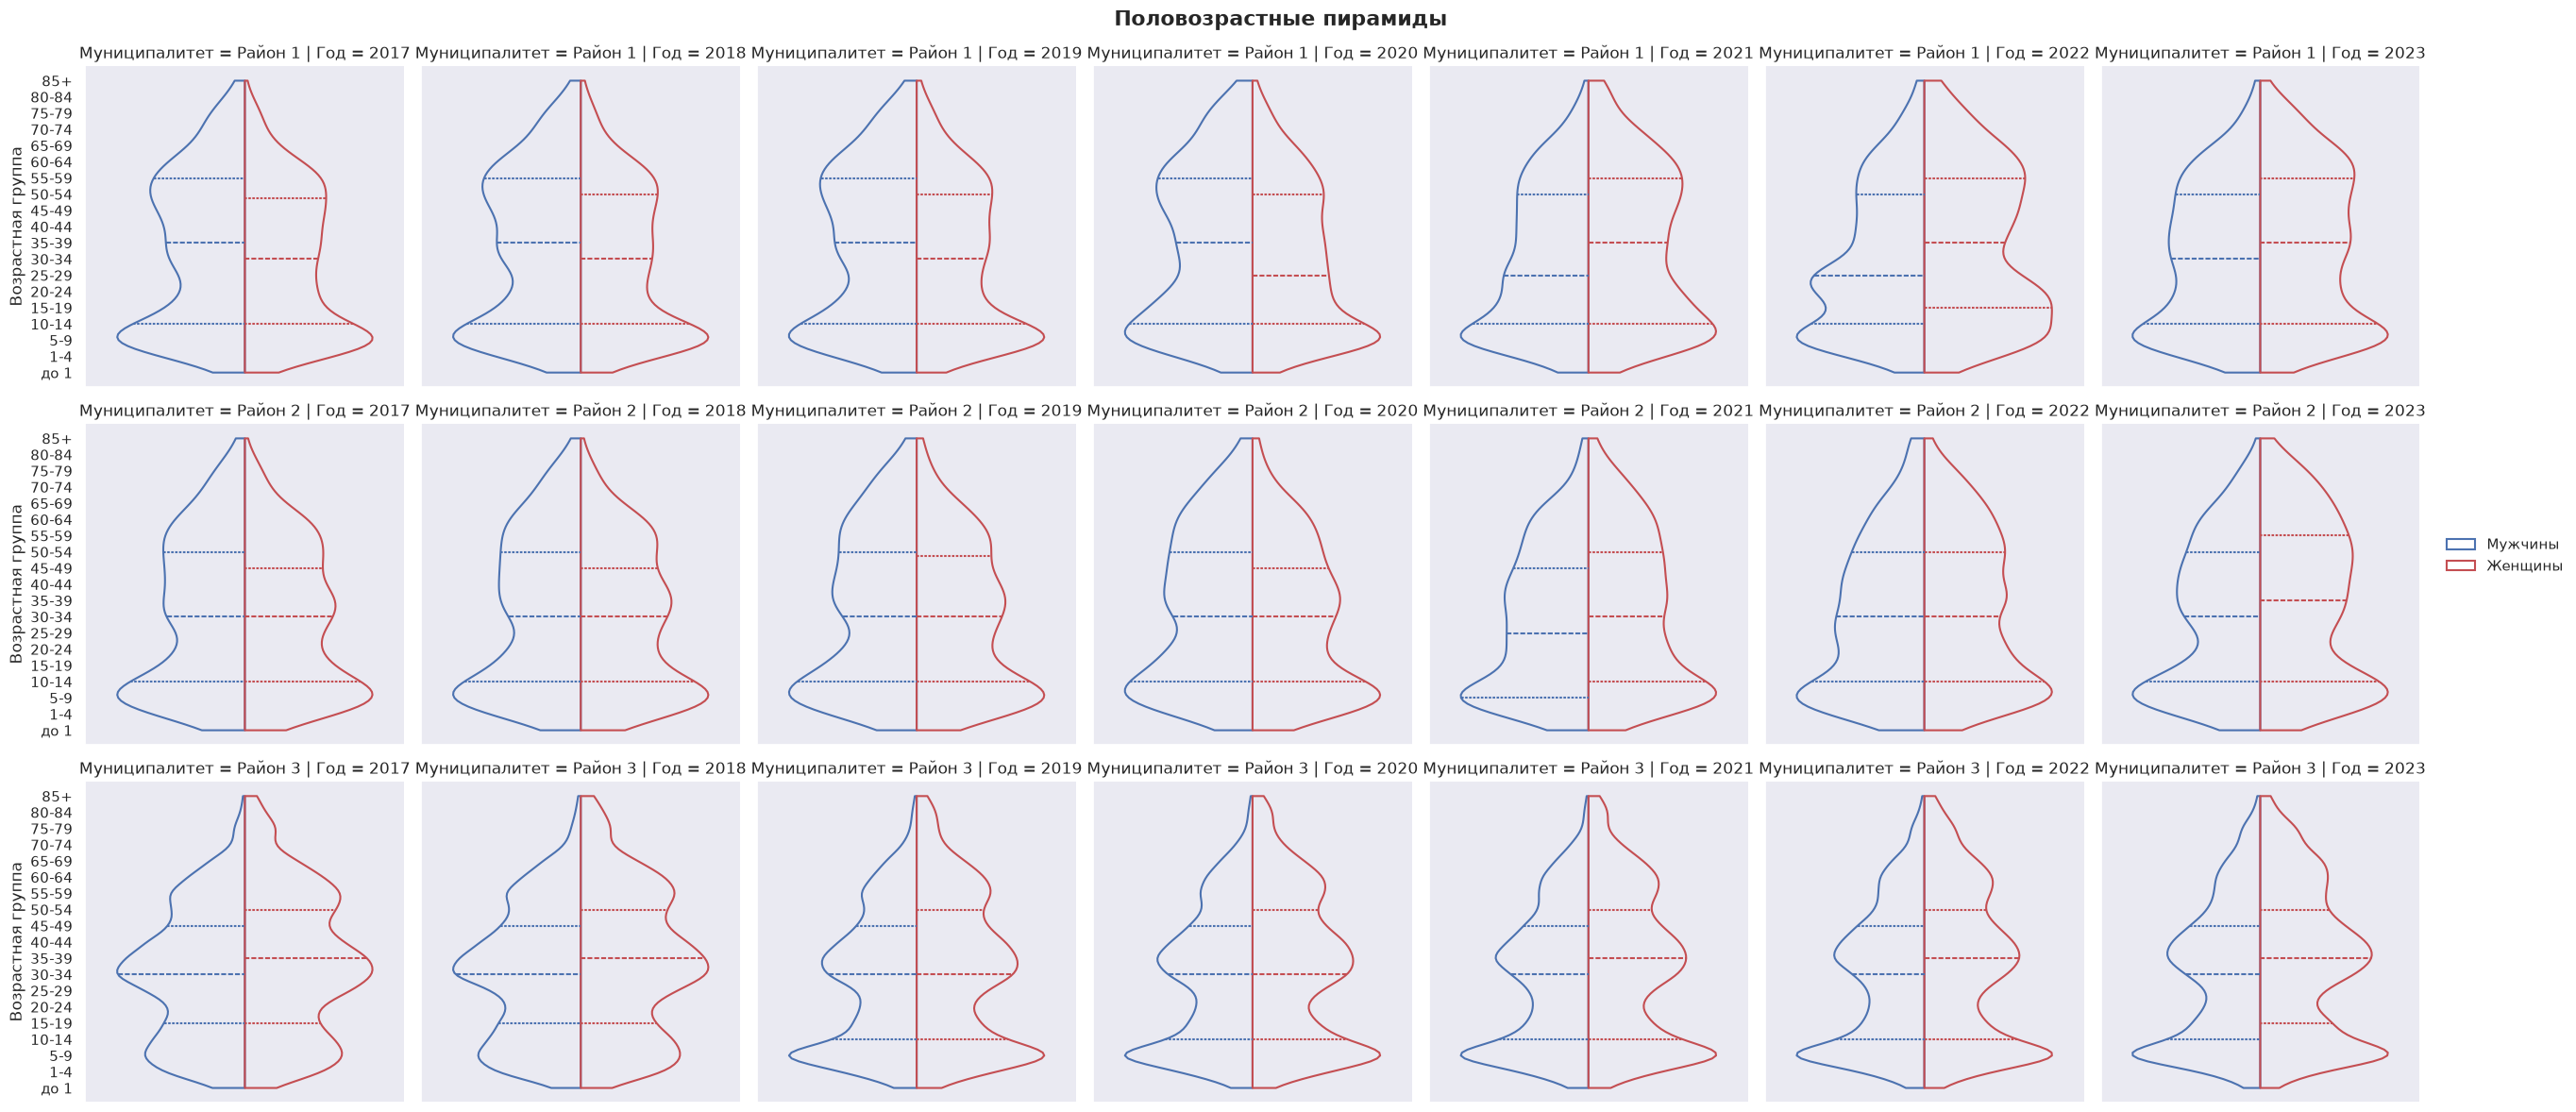

In [18]:
# Построение половозрастных пирамид для всех годов и муниципалитетов с группировкой по муниципалитетам.

# Создание сетки FacetGrid.
g = sns.FacetGrid(df_group_population, col='Год', row='Муниципалитет',
                  height=4, aspect=0.93
                 )
# Создание рисунков в сетке FacetGrid.
g.map_dataframe(sns.violinplot, y="Возрастная группа", hue='Пол',
                split=True, inner="quart", fill=False,
                palette={"Мужчины": "b", "Женщины": "r"}, cut=0,
                hue_order=['Мужчины', 'Женщины']
               )
# Инвертирование оси y.
g.map(invert_y_axis)
# Добавление легенды.
g.add_legend()
# Добавление заголовка
g.fig.suptitle('Половозрастные пирамиды', fontsize=16, fontweight='bold')
# Сдвиг картинки вниз
g.fig.subplots_adjust(top=0.93)

### Число умерших

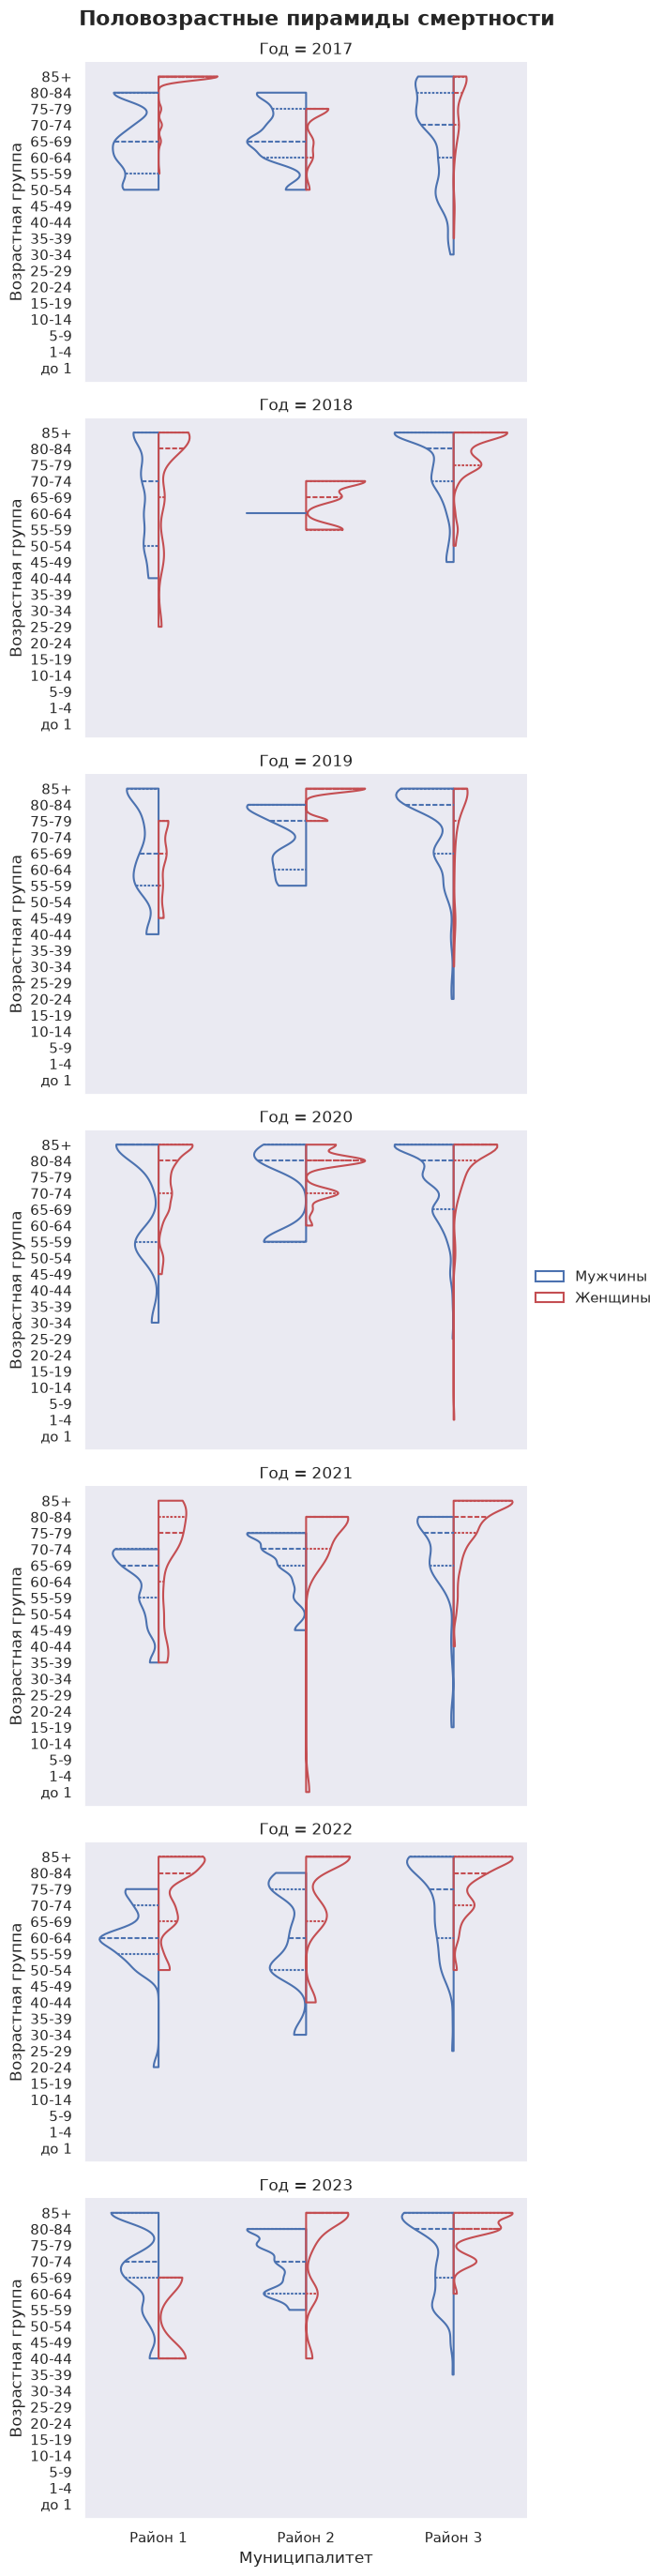

In [19]:
# Построение распределений взвешенного числа умерших по возрастным группам для всех годов и муниципалитетов с группировкой по годам.

# Создание сетки FacetGrid.
g = sns.FacetGrid(df_group_deathes, row='Год',
                  height=4, aspect=1.5
                 )
# Создание рисунков в сетке FacetGrid.
g.map_dataframe(sns.violinplot, x="Муниципалитет", y="Возрастная группа", hue='Пол',
                split=True, inner="quart", fill=False,
                palette={"Мужчины": "b", "Женщины": "r"}, cut=0,
                order=['Район 1', 'Район 2', 'Район 3'],
                hue_order=['Мужчины', 'Женщины']
               )
# Инвертирование оси y.
g.map(invert_y_axis)
# Добавление легенды.
g.add_legend()
# Добавление заголовка
g.fig.suptitle('Половозрастные пирамиды смертности', fontsize=16, fontweight='bold')
# Сдвиг картинки вниз
g.fig.subplots_adjust(top=0.96)

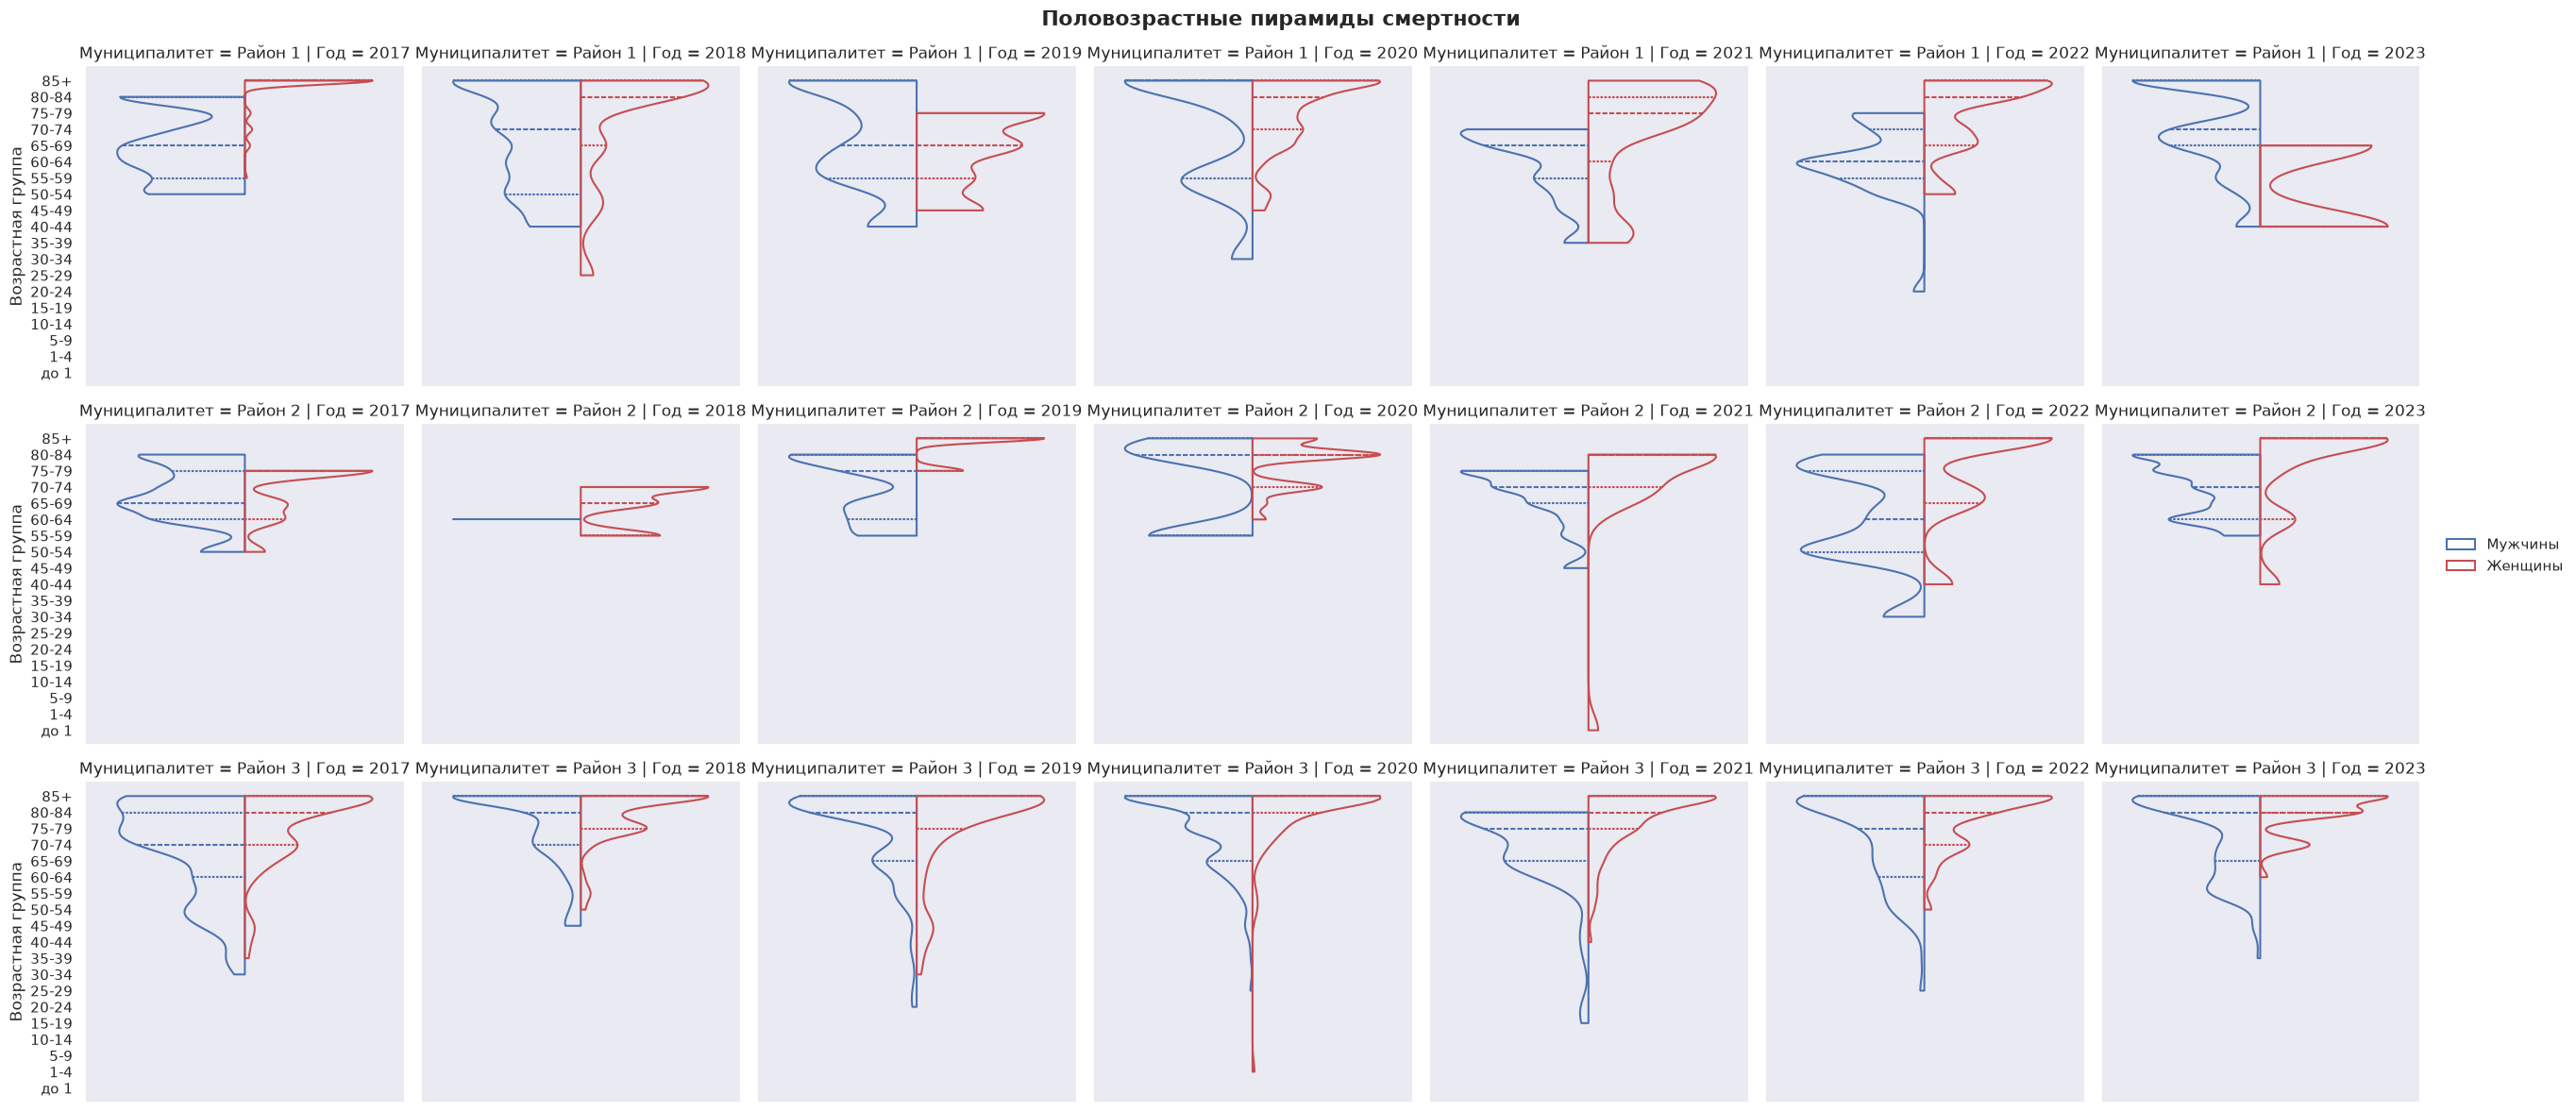

In [20]:
# Построение распределений взвешенного числа умерших по возрастным группам для всех годов и муниципалитетов с группировкой по муниципалитетам.

# Создание сетки FacetGrid.
g = sns.FacetGrid(df_group_deathes, col='Год', row='Муниципалитет',
                  height=4, aspect=0.93
                 )
# Создание рисунков в сетке FacetGrid.
g.map_dataframe(sns.violinplot, y="Возрастная группа", hue='Пол',
                split=True, inner="quart", fill=False,
                palette={"Мужчины": "b", "Женщины": "r"}, cut=0,
                hue_order=['Мужчины', 'Женщины']
               )
# Инвертирование оси y.
g.map(invert_y_axis)
# Добавление легенды.
g.add_legend()
# Добавление заголовка
g.fig.suptitle('Половозрастные пирамиды смертности', fontsize=16, fontweight='bold')
# Сдвиг картинки вниз
g.fig.subplots_adjust(top=0.93)

In [21]:
def draw_pyramid(data, **kwargs):

    order = age_order[::-1]
    # Данные для женщин
    df_women = data[data['Пол'] == 'Женщины']
    # Данные для мужчин
    df_men = data[data['Пол'] == 'Мужчины']
    
    # Текущие оси ячейки
    ax = plt.gca()

    sns.barplot(df_women, x='Взвешенное число умерших', y='Возрастная группа',
                label='Женщины', color='r', errorbar=None, order=order, ax=ax)
    sns.barplot(df_men, x='Взвешенное число умерших', y='Возрастная группа',
                label='Мужчины', color='b', errorbar=None, order=order, ax=ax)

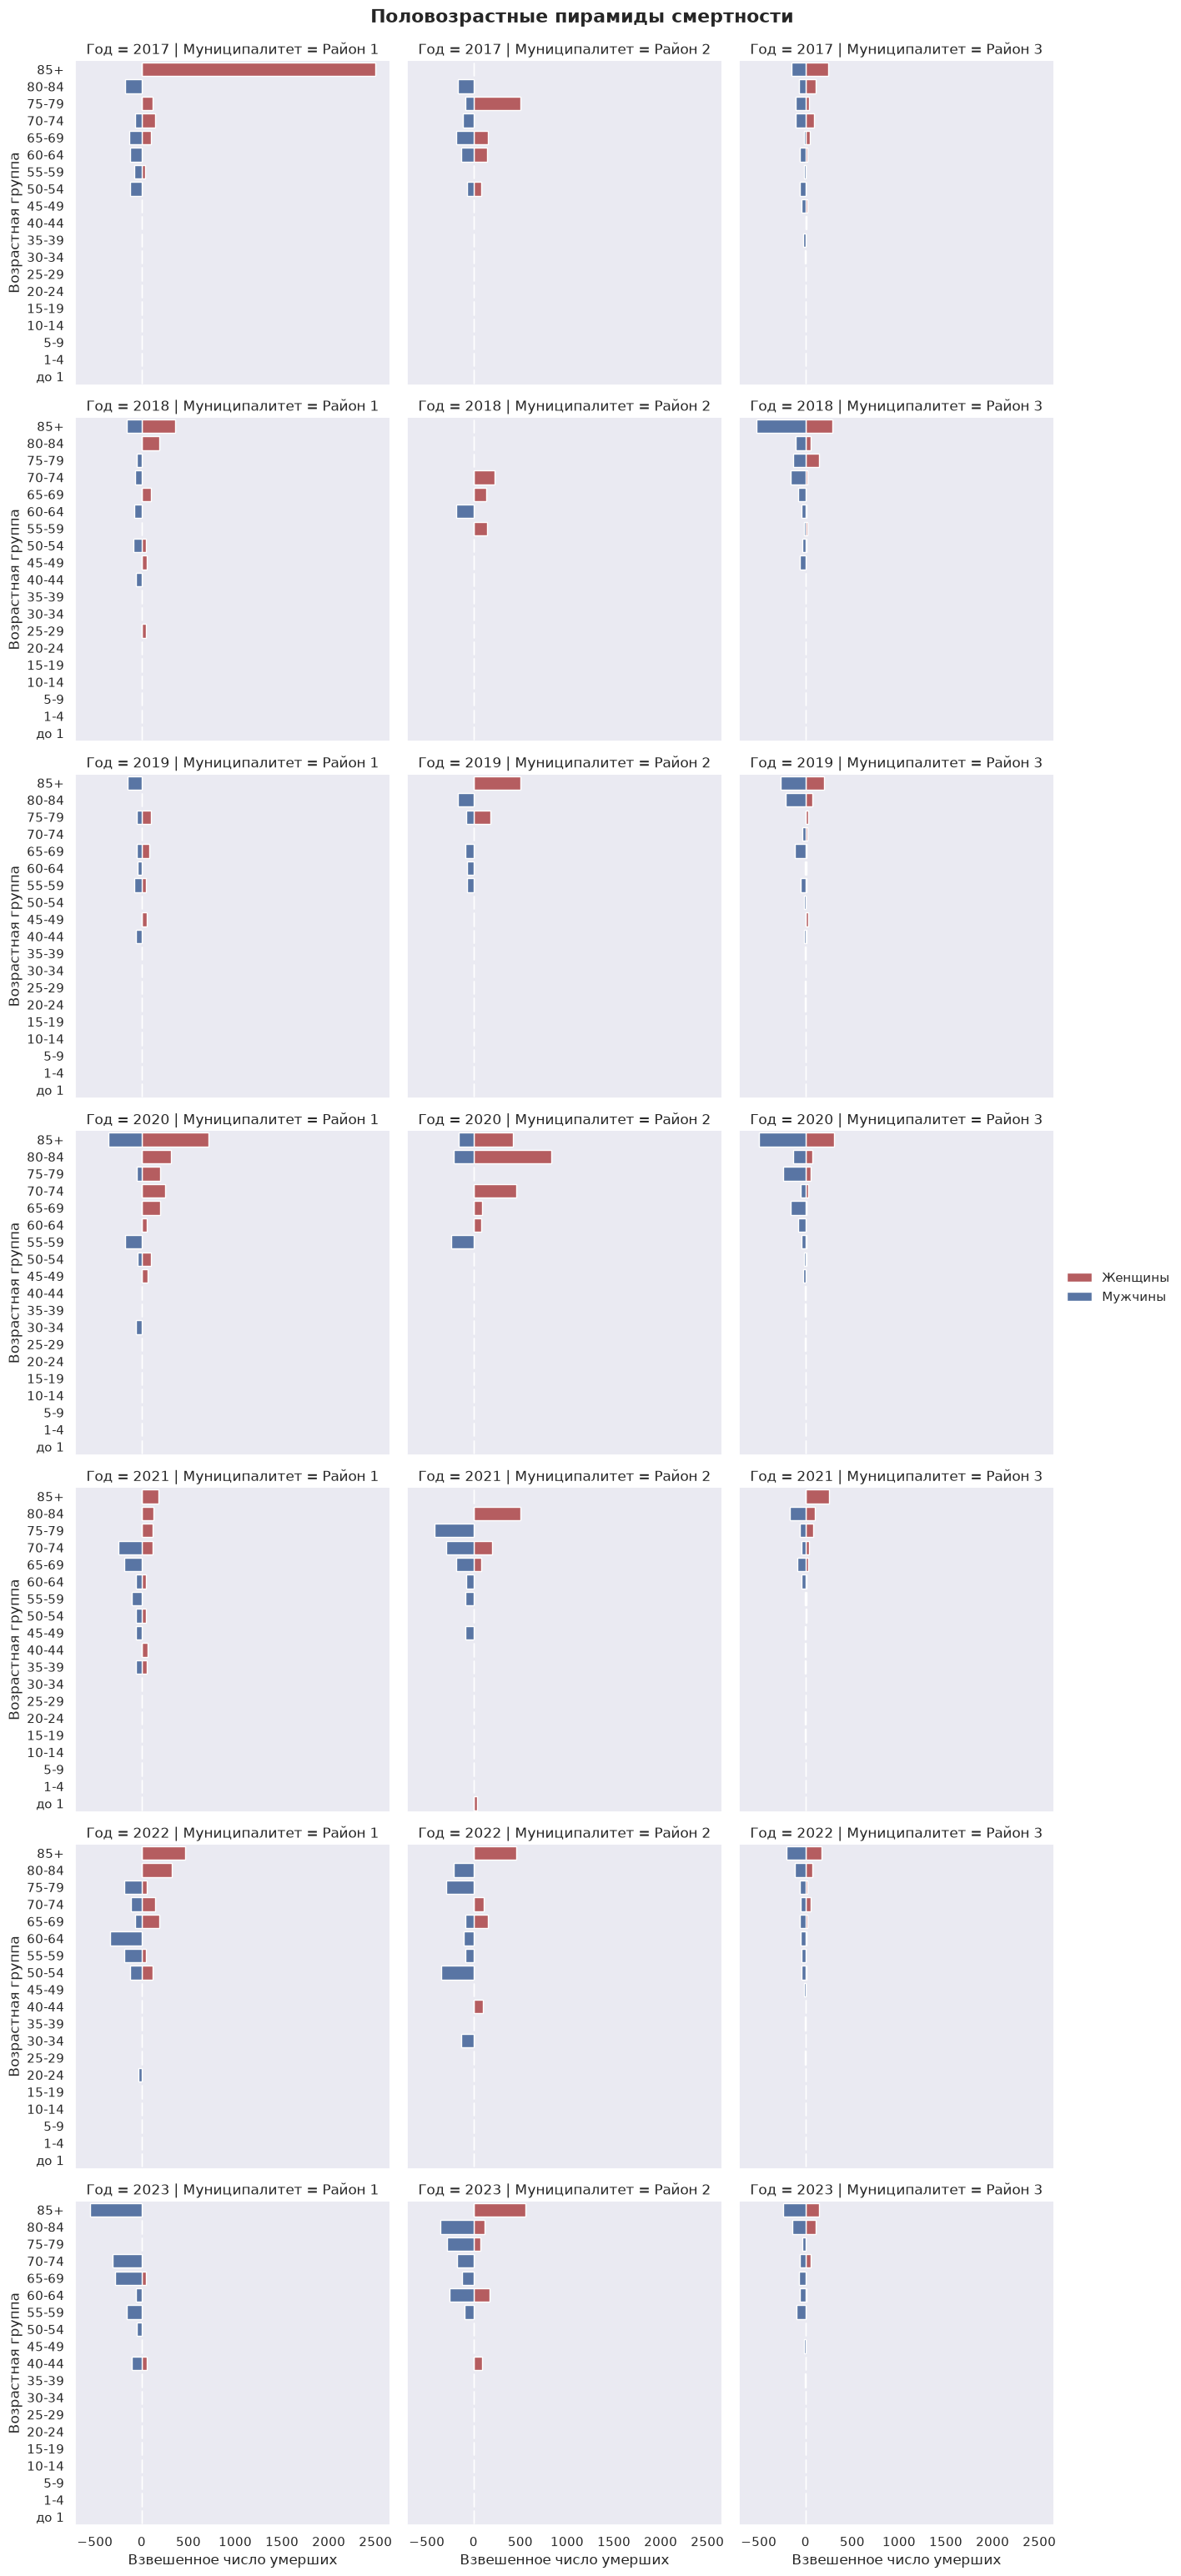

In [22]:
g = sns.FacetGrid(df_group_barplot, 
                  col='Муниципалитет',
                  row='Год',
                  height=4.5, aspect=0.96)
g.map_dataframe(draw_pyramid)
g.fig.suptitle('Половозрастные пирамиды смертности', 
               fontsize=16, fontweight='bold')
g.fig.subplots_adjust(top=0.96)
g.add_legend()

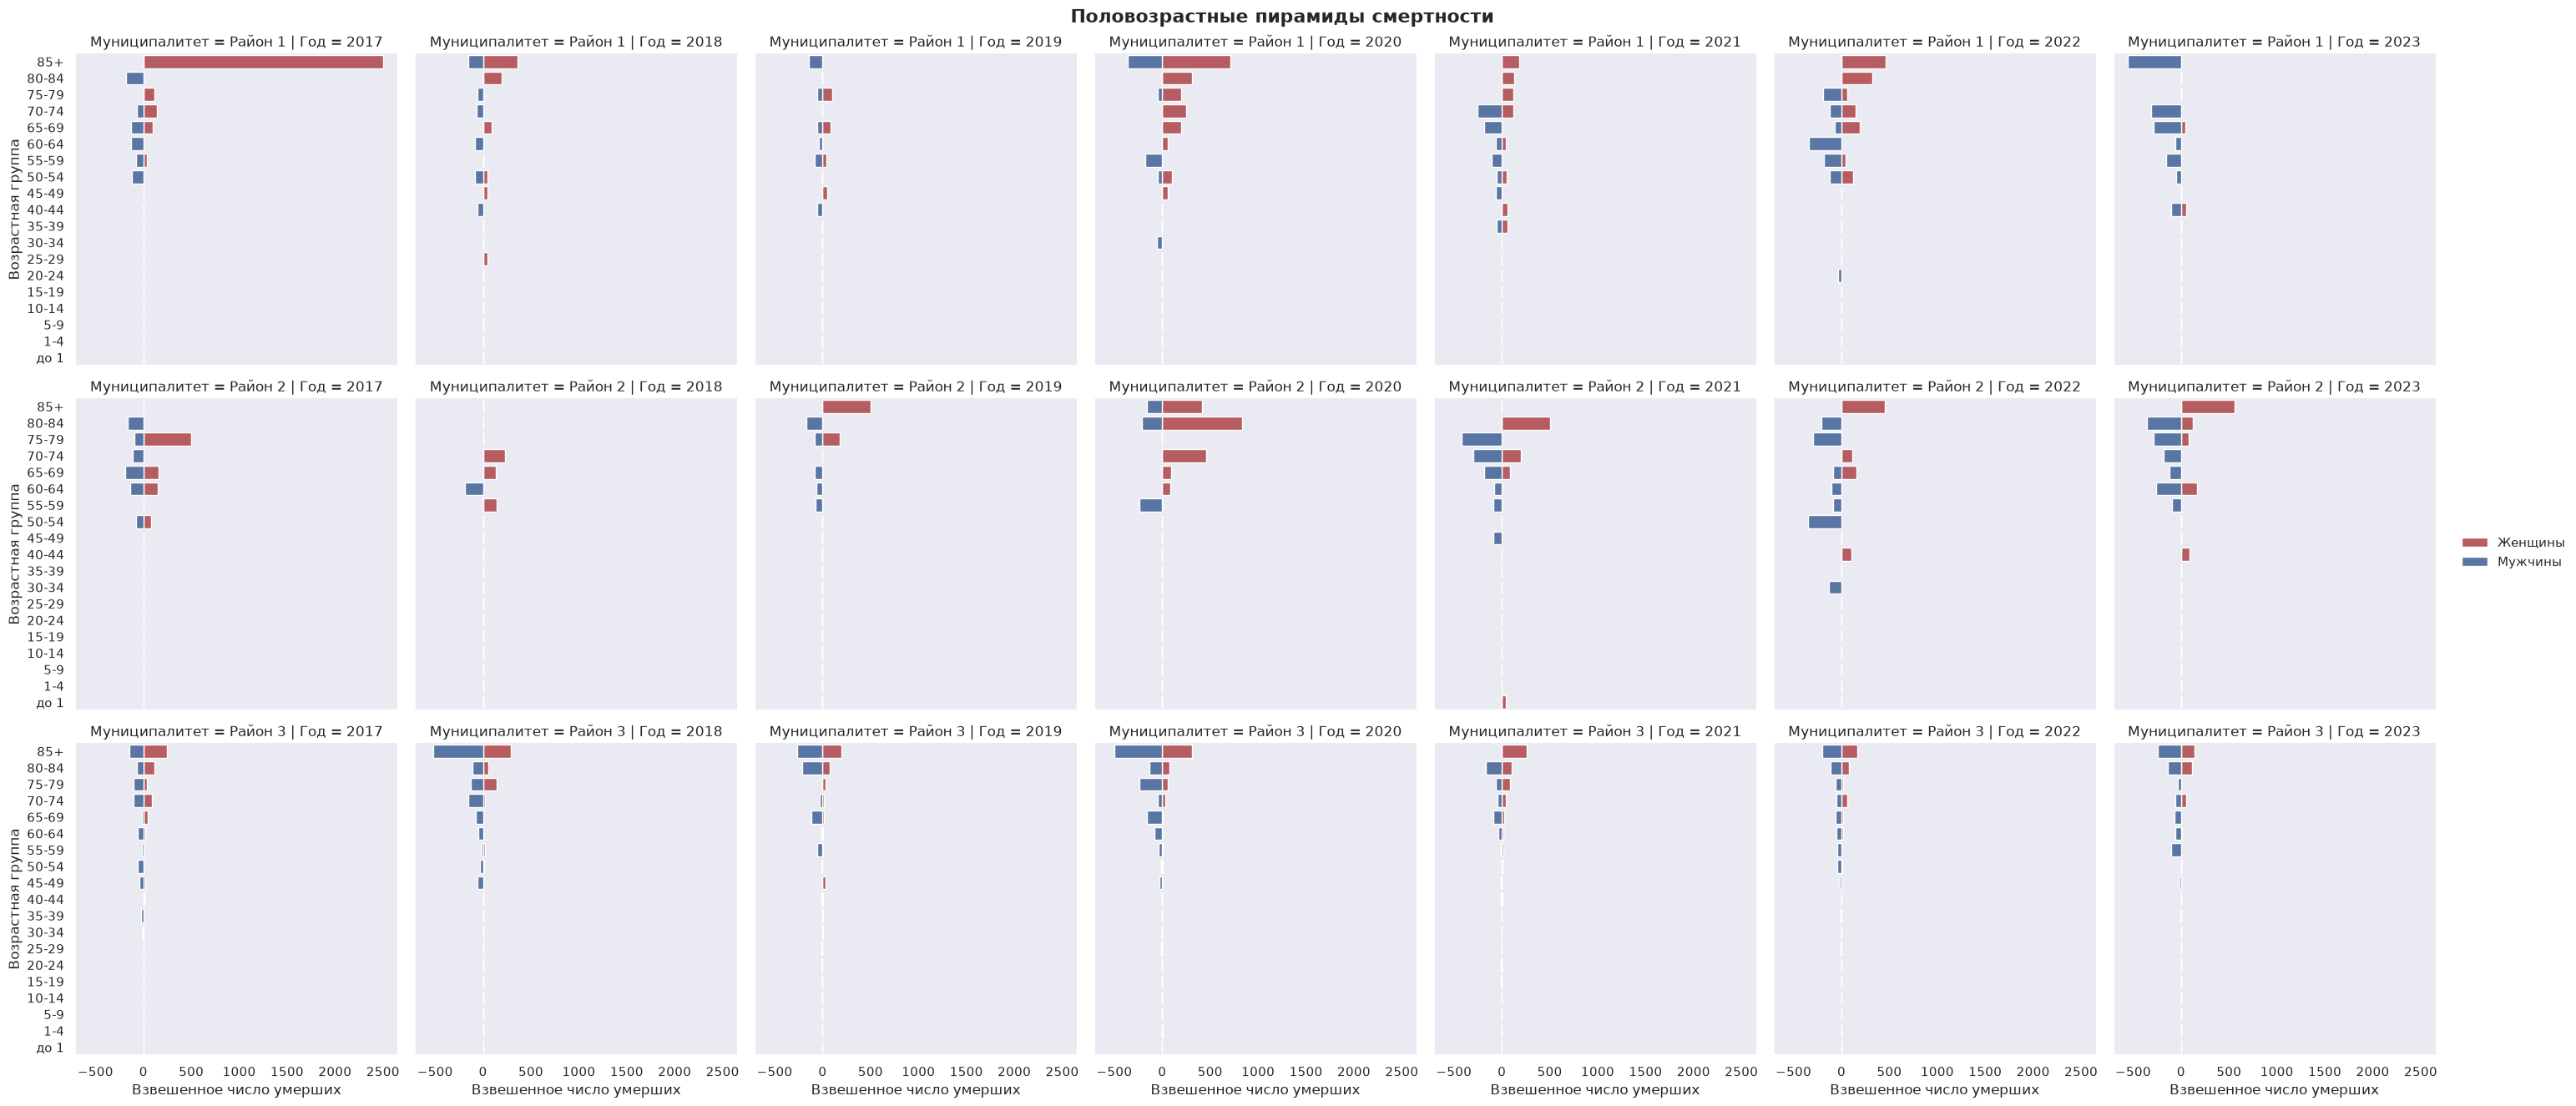

In [23]:
g = sns.FacetGrid(df_group_barplot, 
                  row='Муниципалитет',
                  col='Год',
                  height=4.5, aspect=0.94)
g.map_dataframe(draw_pyramid)
g.fig.suptitle('Половозрастные пирамиды смертности', 
               fontsize=16, fontweight='bold')
g.fig.subplots_adjust(top=0.94)
g.add_legend()

# Распределения чисел умерших по возростам, диагнозам и годам для каждого муниципалитета

In [24]:
# Размножение строк по численности населения в группе для использования violinplot.
df_population=df.loc[df.index.repeat(df['Численность населения'])]
# Размножение строк по числу умерших в группе для использования violinplot.
df_deathes=df.loc[df.index.repeat(df['Взвешенное число умерших'].round())]

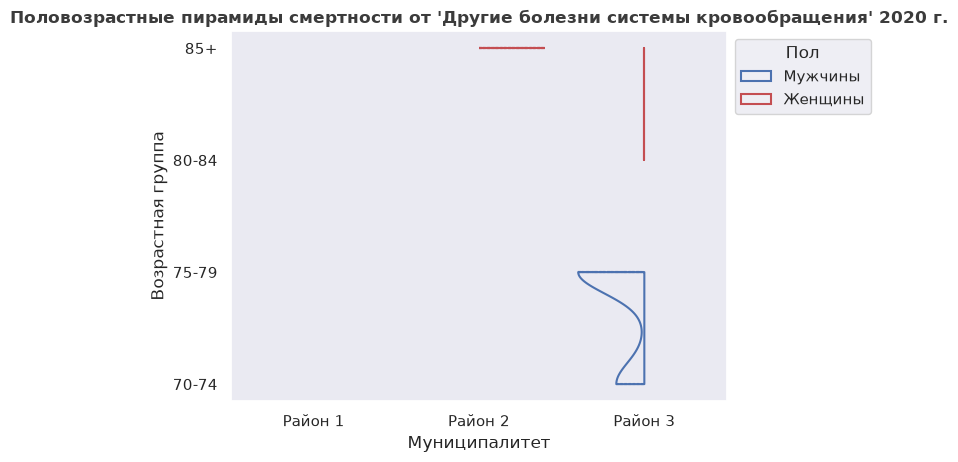

In [25]:
# Построение распределений числа умерших по возрастным группам и полам для выбранного года и причины смерти.

# Задание года
age = 2020
# Задание причины смерти
# cause = 'Острые респираторные заболевания'
# cause = 'Болезни сердца'
# cause = 'Другие болезни органов дыхания'
cause = 'Другие болезни системы кровообращения'

# Создание рисунка
sns.set_theme(style="dark")
fig, ax = plt.subplots()

sns.violinplot(data=df_deathes[(df_deathes['Год']==age)&(df_deathes['Причина смерти']==cause)], x="Муниципалитет", y="Возрастная группа", hue="Пол",
               split=True, inner="quart", fill=False, ax=ax,
               palette={"Мужчины": "b", "Женщины": "r"}, cut=0,
               order=['Район 1', 'Район 2', 'Район 3'],
               hue_order=['Мужчины', 'Женщины']
              )
# Инвертирование оси y.
ax.invert_yaxis()
# Добавление подписи.
ax.set_title("Половозрастные пирамиды смертности от '{}' {} г.".format(cause, age), fontweight='bold', alpha=0.90)
# Перемещение легенды.
legend = plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Пол')